# Project 3 — Multivariate Forecasting (many features in, one target out)

**Goal:** predict the next value of a target series using **multiple input features** at each timestep — and do it with proper **mini-batch** training via `Dataset` + `DataLoader`.

### What's new compared to Project 2
1. **`input_size > 1`.** Each timestep is now a *vector* of features, so windows are `(batch, seq_len, n_features)` with `n_features = 3`. This is the real reason RNNs take a 3-D input — you're finally using that last axis for more than 1.
2. **`Dataset` + `DataLoader`.** Until now we trained on the full batch every epoch (fine for tiny data). Real data needs **mini-batches**. You'll write a tiny `Dataset` and let `DataLoader` handle batching + shuffling.
3. **Enough data to be conclusive.** 3000 timesteps → thousands of windows. The evaluation noise that plagued Project 2 largely disappears.

### The data (synthetic, but honest)
We generate a small **ARX** system (autoregressive + exogenous inputs):

$$A_t = 0.6\,A_{t-1} - 0.2\,A_{t-2} + 0.5\,B_{t-1} + 0.3\,C_{t-2} + \text{weekly}_t + \varepsilon_t$$

The target `A` depends on its **own past** *and* on the other features `B`, `C` at a **lag**. So a multivariate model (seeing B and C) *should* beat a univariate one that sees only A's history. That's the hypothesis you'll test.

### How to use this notebook
Three **`# 🛠️ TODO`**s, all about the new mechanics:
- finish the `Dataset` (`__len__`, `__getitem__`),
- set the model's `input_size` to the number of features,
- write the **mini-batch** training loop.

---

## Step 0 — Imports & device
*(provided)*

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Step 1 — Generate the multivariate data
*(provided)*

Three features: `A` (the target driver), `B`, `C`. The target we forecast is the **next value of `A`**.

features shape: (3000, 3) | target = next value of column 0 (A)


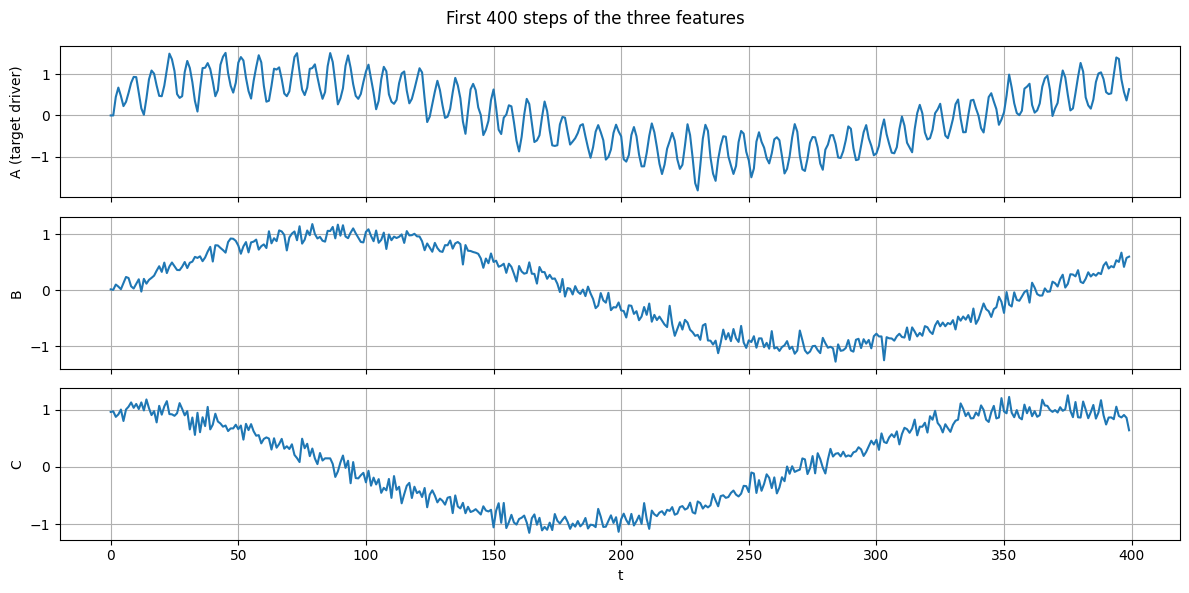

In [20]:
rng = np.random.default_rng(0)
n = 3000
t = np.arange(n)

B = np.sin(2 * np.pi * t / 365) + 0.10 * rng.standard_normal(n)   # e.g. temperature
C = np.cos(2 * np.pi * t / 365) + 0.10 * rng.standard_normal(n)   # e.g. daylight
weekly = 0.30 * np.sin(2 * np.pi * t / 7)

A = np.zeros(n)
for k in range(2, n):
    A[k] = (0.6 * A[k-1] - 0.2 * A[k-2]
            + 0.5 * B[k-1] + 0.3 * C[k-2]
            + weekly[k] + 0.10 * rng.standard_normal())

features = np.stack([A, B, C], axis=1).astype(np.float32)  # (n, 3)
# features = features[:,0:1]
N_FEATURES = features.shape[1]
print("features shape:", features.shape, "| target = next value of column 0 (A)")

fig, ax = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, name in enumerate(["A (target driver)", "B", "C"]):
    ax[i].plot(features[:400, i]); ax[i].set_ylabel(name); ax[i].grid(True)
ax[-1].set_xlabel("t"); plt.suptitle("First 400 steps of the three features"); plt.tight_layout(); plt.show()

## Step 2 — Time split + scaling (fit on train only)
*(provided — same leakage discipline as Project 2, now for a feature matrix)*

`MinMaxScaler` on a 2-D array scales **each column independently**, which is exactly what we want. We keep a **separate** scaler for the target so we can invert predictions back to A's units.

In [21]:
split_raw = int(0.8 * n)

feat_scaler = MinMaxScaler().fit(features[:split_raw])            # fit on train rows only
feats_scaled = feat_scaler.transform(features).astype(np.float32)

target_scaler = MinMaxScaler().fit(features[:split_raw, 0:1])     # target = column 0 (A)
target_scaled = target_scaler.transform(features[:, 0:1]).astype(np.float32).ravel()

print("feats_scaled:", feats_scaled.shape, "| target_scaled:", target_scaled.shape)

feats_scaled: (3000, 3) | target_scaled: (3000,)


## Step 3 — Windowing (multivariate)
*(provided)*

Same sliding window, but each element is now a **feature vector**. `X` becomes `(n_samples, seq_len, n_features)`; the target is the next value of `A`.

In [29]:
def make_windows_multi(feats, target, seq_len):
    X, y = [], []
    for i in range(len(feats) - seq_len):
        X.append(feats[i : i + seq_len])     # (seq_len, n_features)
        y.append(target[i + seq_len])        # scalar: next A
    X = np.asarray(X, dtype=np.float32)                 # (n, seq_len, n_features)
    y = np.asarray(y, dtype=np.float32)[:, None]        # (n, 1)
    return X, y

SEQ_LEN = 40
X, y = make_windows_multi(feats_scaled, target_scaled, SEQ_LEN)

split = split_raw - SEQ_LEN
X_train, y_train = X[:split], y[:split]
X_test,  y_test  = X[split:], y[split:]
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

X_train: (2360, 40, 3) | y_train: (2360, 1)
X_test : (600, 40, 3) | y_test : (600, 1)


## Step 4 — 🛠️ Dataset + DataLoader

So far we shoved the *entire* training set through the model each step. Real datasets are too big for that — we train on **mini-batches**. PyTorch's `DataLoader` does the batching (and shuffling) for you, but it needs a `Dataset` that can answer two questions:
- **`__len__`** → how many samples are there?
- **`__getitem__(idx)`** → give me sample `idx` as `(x, y)`.

### A subtlety you should notice
In Project 1 we said *never shuffle a time series*. Here we **do** set `shuffle=True` — and that's fine! Each **window** is already a self-contained training example; shuffling the *order of windows* doesn't leak the future, because the time-ordering **inside** each window is preserved and the train/test split was done by time. Shuffling windows just decorrelates gradients (good for SGD).

Fill in the two methods.

In [38]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)   # (n, seq_len, n_features)
        self.y = torch.from_numpy(y)   # (n, 1)

    def __len__(self):
        if len(self.X) != len(self.y):
            raise ValueError(
                "Features and targets must have same length. "
                f"Got len(X)= {len(self.X)} and len(y)={len(self.y)}"
            )
        else:
            return(len(self.y))
        # 🛠️ TODO: return the number of samples
        # raise NotImplementedError

    def __getitem__(self, idx):
        return (self.X[idx,:,:], self.y[idx,:])
        # 🛠️ TODO: return the (x, y) pair at position idx
        # raise NotImplementedError


train_dl = DataLoader(SeqDataset(X_train, y_train), batch_size=16, shuffle=True)
test_dl  = DataLoader(SeqDataset(X_test,  y_test),  batch_size=256, shuffle=False)

# sanity check: one batch should be (64, SEQ_LEN, N_FEATURES) and (64, 1)
xb, yb = next(iter(train_dl))
print("batch X:", xb.shape, "| batch y:", yb.shape)

batch X: torch.Size([16, 40, 3]) | batch y: torch.Size([16, 1])


## Step 5 — 🛠️ Model (now with N_FEATURES inputs)

The architecture is the same one you already built — the **only** change is `input_size` must equal the number of features (3), not 1. Everything else (`h_n`/tuple handling) is unchanged.

Set `input_size` correctly where marked.

In [39]:
class Forecaster(nn.Module):
    def __init__(self, cell="GRU", input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[cell]
        self.rnn = rnn_cls(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h = self.rnn(x)
        last = h[0][-1] if isinstance(h, tuple) else h[-1]
        return self.fc(last)


# 🛠️ TODO: pass input_size = N_FEATURES so the model accepts 3-feature timesteps
model = Forecaster(cell="GRU", input_size=N_FEATURES, hidden_size=64).to(device)
print(model)

# quick shape check (uncomment after building the model):
with torch.no_grad():
    print("out:", model(xb.to(device)).shape)   # expect (64, 1)

Forecaster(
  (rnn): GRU(3, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
out: torch.Size([16, 1])


## Step 6 — 🛠️ Mini-batch training loop

Same 5 steps you know — but now the **inner loop iterates over `train_dl`**, one mini-batch at a time. Don't forget to move each batch to `device`.

```python
for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        # 5 steps: zero_grad -> forward -> loss -> backward -> step
```

In [40]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 100
epoch_losses = []
for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        # 🛠️ TODO: the 5 steps on this mini-batch; append loss.item() to batch_losses
        # raise NotImplementedError("Implement the mini-batch training step")
        # step 1: clear out gradient buffers
        optimizer.zero_grad()

        #step 2: Forward
        y_pred = model(xb)

        # step 3: Calculate loss
        loss_b = criterion(y_pred, yb)

        # step 4: PyTorch magic: backward gradient calculation
        loss_b.backward()

        # step 5: weight update
        optimizer.step()

        batch_losses.append(loss_b.cpu().detach().numpy().ravel())
        
    epoch_losses.append(np.mean(batch_losses))
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch+1:2d} | train MSE {epoch_losses[-1]:.5f}")

epoch  5 | train MSE 0.00151
epoch 10 | train MSE 0.00118
epoch 15 | train MSE 0.00111
epoch 20 | train MSE 0.00101
epoch 25 | train MSE 0.00095
epoch 30 | train MSE 0.00095
epoch 35 | train MSE 0.00097
epoch 40 | train MSE 0.00093
epoch 45 | train MSE 0.00092
epoch 50 | train MSE 0.00092
epoch 55 | train MSE 0.00091
epoch 60 | train MSE 0.00092
epoch 65 | train MSE 0.00088
epoch 70 | train MSE 0.00094
epoch 75 | train MSE 0.00093
epoch 80 | train MSE 0.00091
epoch 85 | train MSE 0.00089
epoch 90 | train MSE 0.00090
epoch 95 | train MSE 0.00089
epoch 100 | train MSE 0.00091


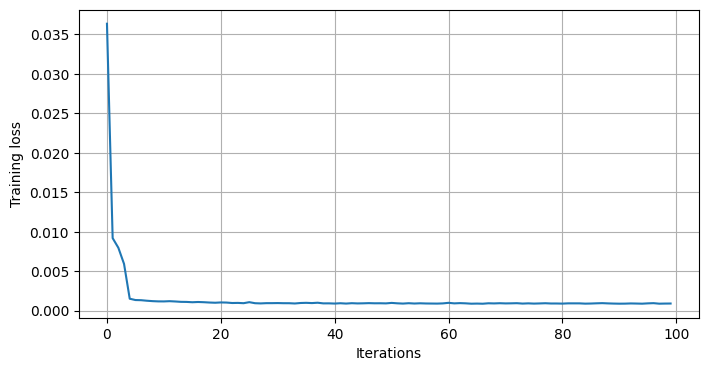

In [41]:
# print training loss in epochs
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(epoch_losses)
ax.set_xlabel("Iterations")
ax.set_ylabel("Training loss")
ax.grid(True)



## Step 7 — Evaluate & plot
*(provided)*

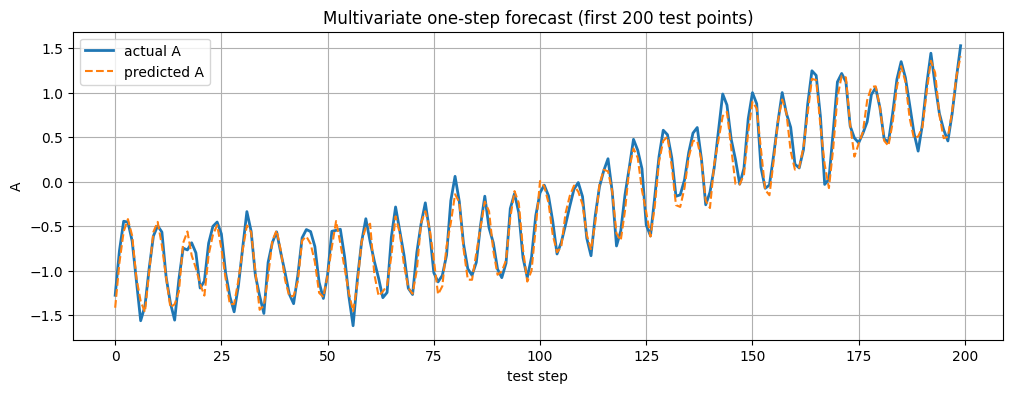

Test MSE (original units): 0.01144


In [42]:
model.eval()
preds = []
with torch.no_grad():
    for xb, yb in test_dl:
        preds.append(model(xb.to(device)).cpu().numpy())
preds = np.concatenate(preds).ravel()

# back to original units
pred_A = target_scaler.inverse_transform(preds[:, None]).ravel()
true_A = target_scaler.inverse_transform(y_test).ravel()

plt.figure(figsize=(12, 4))
plt.plot(true_A[:200], label="actual A", linewidth=2)
plt.plot(pred_A[:200], "--", label="predicted A")
plt.title("Multivariate one-step forecast (first 200 test points)")
plt.xlabel("test step"); plt.ylabel("A"); plt.legend(); plt.grid(True)
plt.show()

test_mse = np.mean((pred_A - true_A) ** 2)
print(f"Test MSE (original units): {test_mse:.5f}")

Test MSE (original units): 0.01206 for multivariate model
Test MSE (original units): 0.01786 for univariate model
with seq_len 3 for multivariate model the Test MSE: 0.01710
with seq_len 40, epoch 100:  Test MSE = 0.01027

## Step 8 — 🛠️ The payoff experiment: does multivariate actually help?

This is the whole point. Retrain the **same model** but feed it **only feature A** (univariate) and compare the test MSE to the multivariate version.

**Hint:** you already have the machinery. Build univariate windows with `make_windows_multi(feats_scaled[:, 0:1], target_scaled, SEQ_LEN)` (note the `0:1` keeps it 2-D), rebuild the loaders with `input_size=1`, retrain, and compare.

Write your prediction *first*, then test it:
> My prediction: The result with univariate features will be degrade_______ 

Then answer:
1. Did adding B and C lower the test MSE? By how much? -> yes indeed by approx 0.005
2. The target depends on `B[t-1]` and `C[t-2]`. Is `SEQ_LEN=20` enough to see those lags? What happens with `SEQ_LEN=3`? -> Actually `SEQ_LEN=20` works good, however `SEQ_LEN=3` does not because, even if the target depends of `B[t-1]` and `C[t-2]`, the A,B and C itself follows a sinusoidal pattern. The models must be able to learn these patterns in order to work well.
3. **Batching:** try `batch_size` of 16 vs 256. What happens to training speed and the smoothness of the loss curve? with `batch_size=16` the training loss becomes smoother, training speed decreases. Because then per epoch the number of batches to train increases. 
4. **Reflect:** why is shuffling windows OK here, when shuffling the raw series in Project 1 was forbidden?
Shuffling windows is OK because we are not shuffling elements of a window but windows which preserve the trend inside the window
---
Fill in the three 🛠️ TODOs, run it, and send me your multivariate-vs-univariate MSE gap. Then we go to **Project 4 (seq2seq multi-step)**.

### Summary
1. To use PyTorch dataloader one needs to create DataSet which contains: `__len__` and `__getitem__`.
2. Always keep in mind the noisefloor of the model. No model and architecture can perform better than this.
3. Univariate model is blind towards a multivariate process. We need to somehow figure out for a given process the right order!
4. Bigger `SEQ_LEN` buys the ability to represent **slow/seasonal structure**.